✓ All plots generated successfully


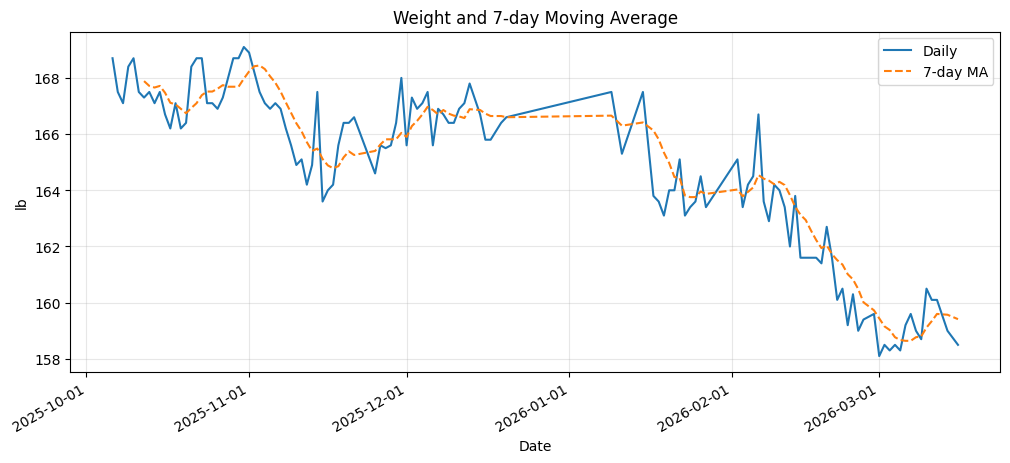

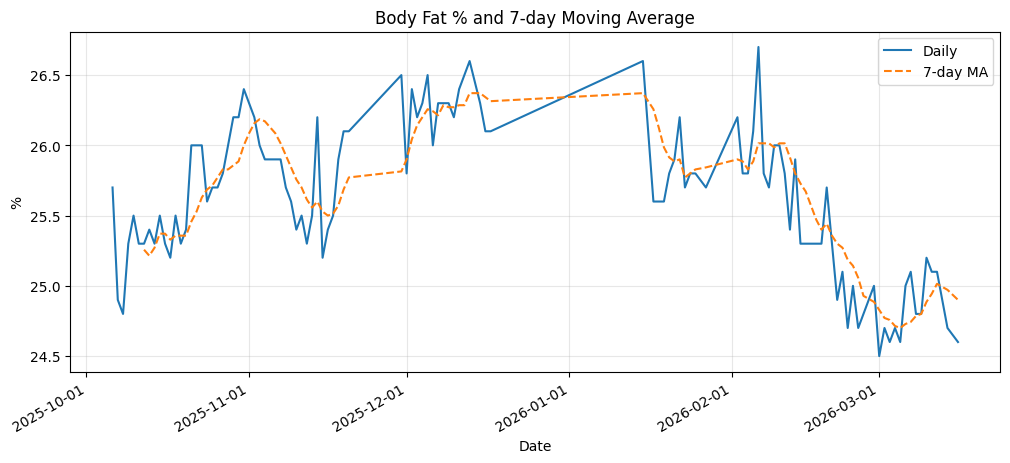

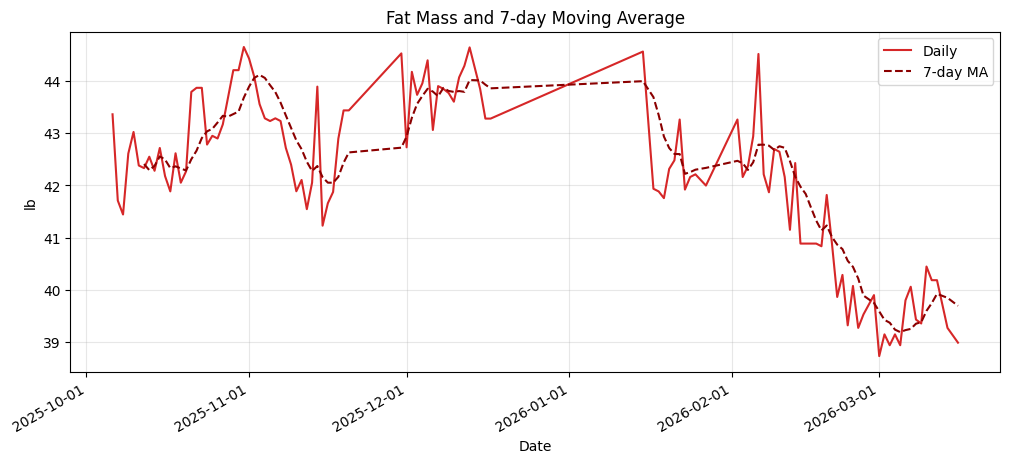

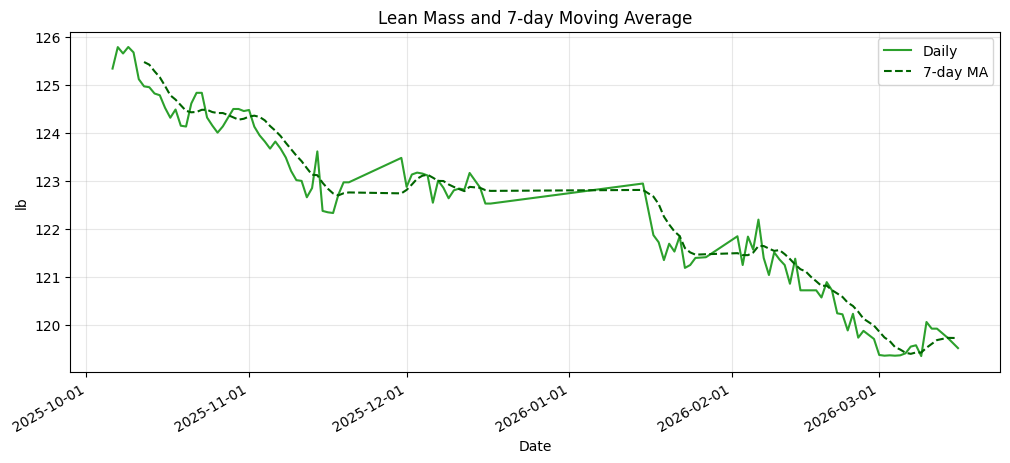

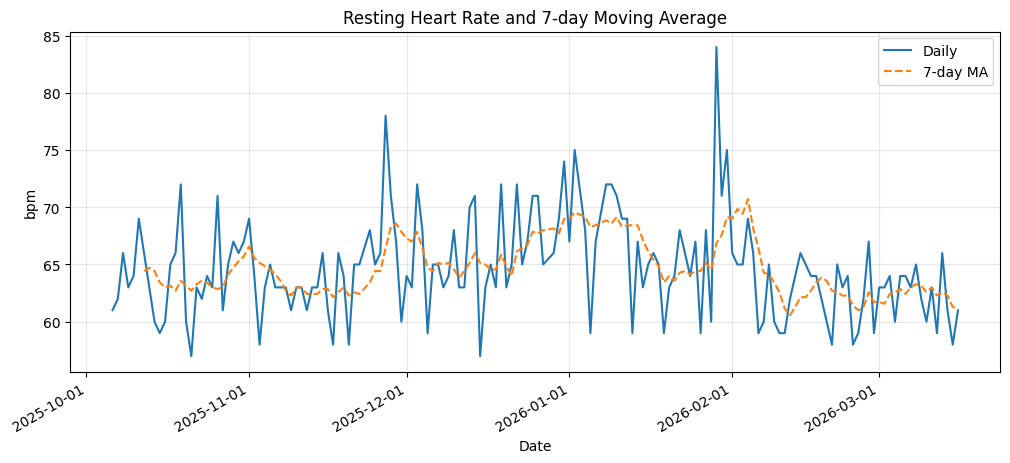

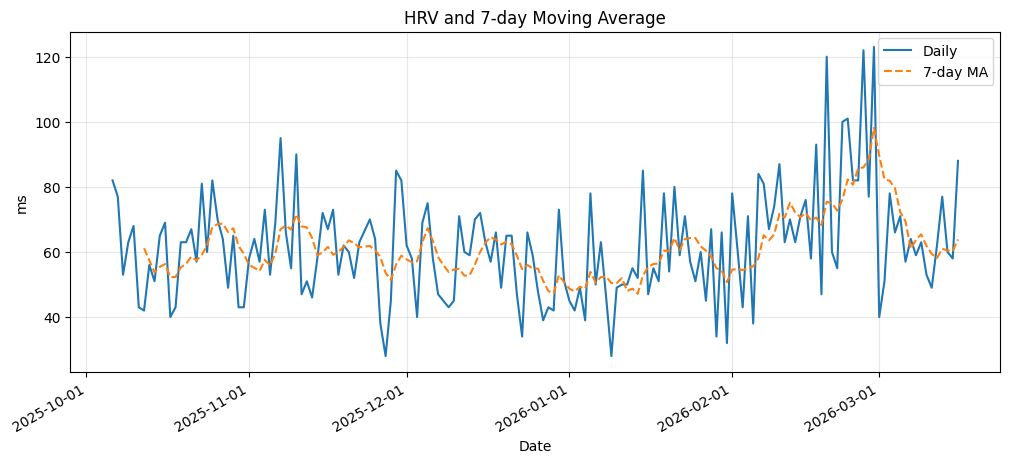

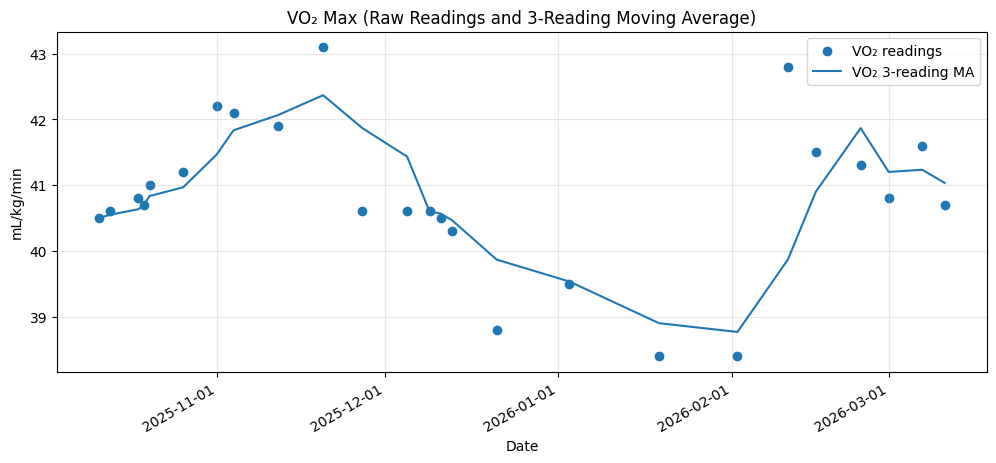

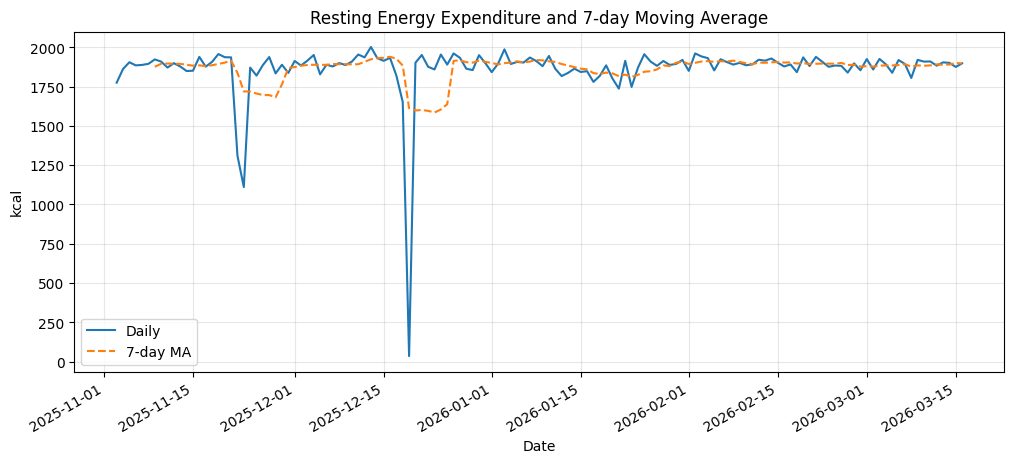

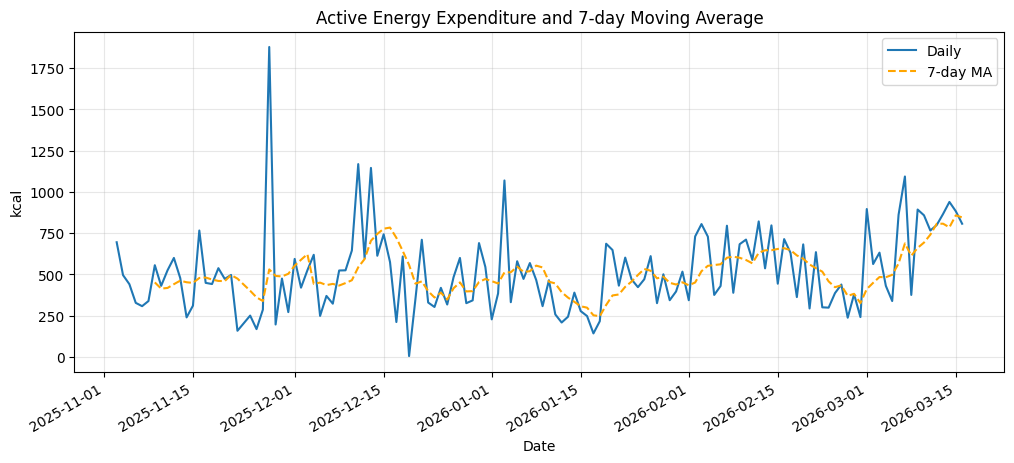

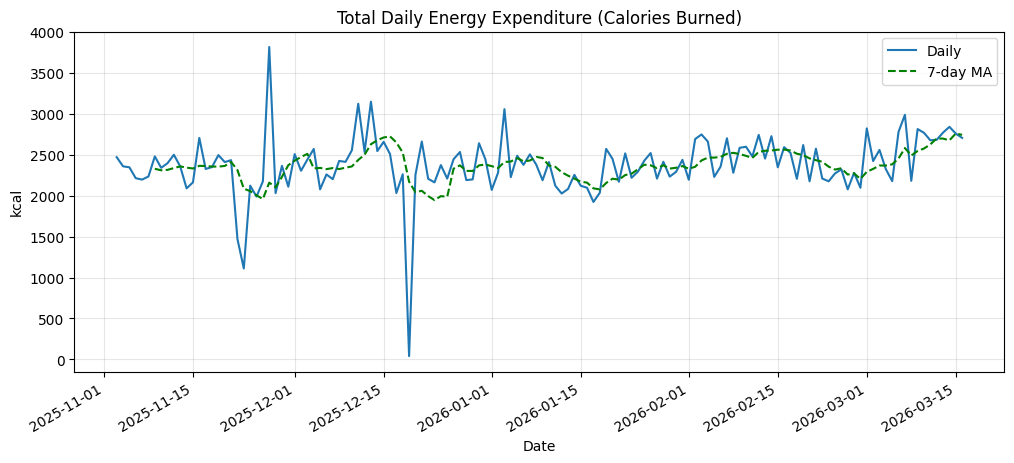

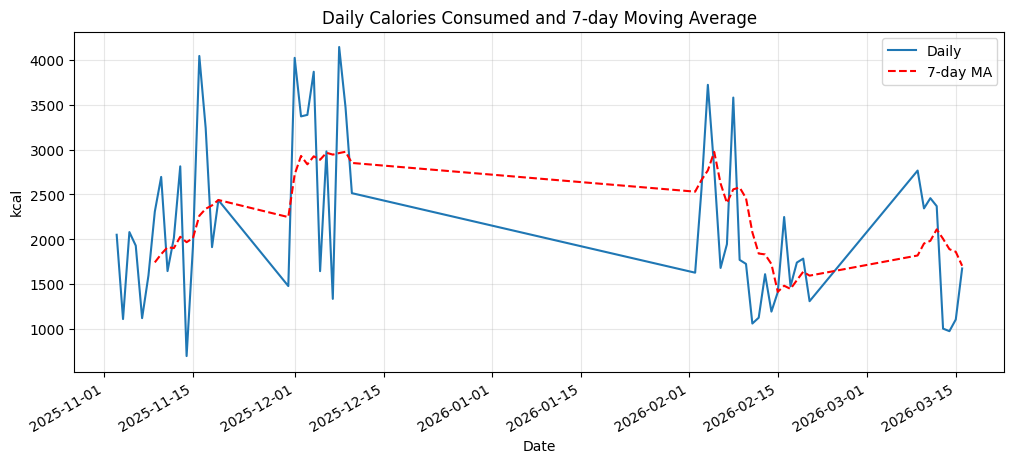

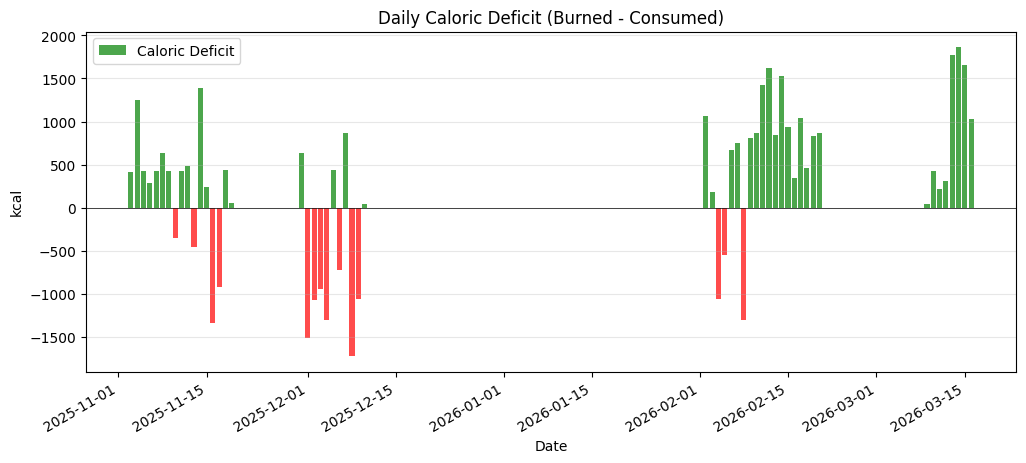

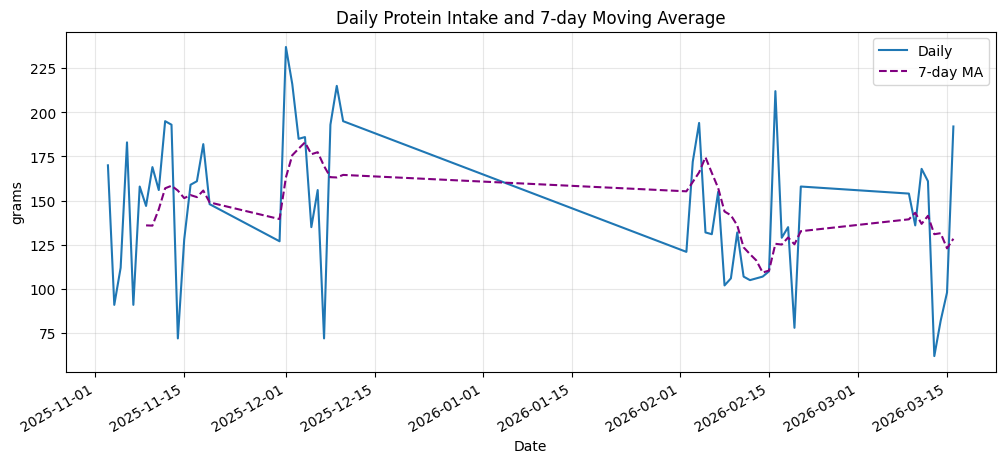

In [3]:
# Weight and health metrics tracking with moving averages
import matplotlib.pyplot as plt
import pandas as pd
from matplotlib.dates import DateFormatter

# Read data from CSV file
csv_path = "Blueprint Tracker - Metrics.csv"
df_csv = pd.read_csv(csv_path, index_col=0)

# Transpose and parse the data
df = df_csv.T
df.index = pd.to_datetime(df.index, format="%m/%d/%Y")
df = df.sort_index()

# Convert columns to numeric types, handling percentages and empty values
df["Weight"] = pd.to_numeric(df["Weight"], errors="coerce").astype("float64")
df["Body Fat %"] = df["Body Fat %"].str.rstrip("%").astype("float64")
df["RHR"] = pd.to_numeric(df["RHR"], errors="coerce").astype("Float64")
df["HRV"] = pd.to_numeric(df["HRV"], errors="coerce").astype("Float64")
df["VO2 Max"] = pd.to_numeric(df["VO2 Max"], errors="coerce").astype("Float64")
df["Resting Energy"] = pd.to_numeric(df["Resting Energy"], errors="coerce").astype("Float64")
df["Active Energy"] = pd.to_numeric(df["Active Energy"], errors="coerce").astype("Float64")
df["Calories Burned"] = pd.to_numeric(df["Calories Burned"], errors="coerce").astype("Float64")
df["Calories Consumed"] = pd.to_numeric(df["Calories Consumed"], errors="coerce").astype("Float64")
df["Deficit"] = pd.to_numeric(df["Deficit"], errors="coerce").astype("Float64")
df["Protein"] = pd.to_numeric(df["Protein"], errors="coerce").astype("Float64")

# Rename columns to match our convention
df = df.rename(columns={"Body Fat %": "BodyFatPct", "VO2 Max": "VO2"})

# Derive fat mass and lean mass (only where both weight and body fat are available)
df["FatMass"] = df["Weight"] * df["BodyFatPct"] / 100
df["LeanMass"] = df["Weight"] - df["FatMass"]

# Rolling averages with min_periods=7 on non-NA values
weight_valid = df["Weight"].dropna()
ma7_weight = weight_valid.rolling(window=7, min_periods=7).mean()

bf_valid = df["BodyFatPct"].dropna()
ma7_bf = bf_valid.rolling(window=7, min_periods=7).mean()

fat_valid = df["FatMass"].dropna()
ma7_fat = fat_valid.rolling(window=7, min_periods=7).mean()

lean_valid = df["LeanMass"].dropna()
ma7_lean = lean_valid.rolling(window=7, min_periods=7).mean()

rhr_valid = df["RHR"].dropna()
ma7_rhr = rhr_valid.rolling(window=7, min_periods=7).mean()

hrv_valid = df["HRV"].dropna()
ma7_hrv = hrv_valid.rolling(window=7, min_periods=7).mean()

# VO2 valid only for non-missing; 3-reading MA on those points
vo2_valid = df["VO2"].dropna()
if len(vo2_valid) > 0:
    vo2_ma3 = vo2_valid.rolling(window=3, min_periods=1).mean()

# Energy metrics moving averages
resting_valid = df["Resting Energy"].dropna()
ma7_resting = resting_valid.rolling(window=7, min_periods=7).mean()

active_valid = df["Active Energy"].dropna()
ma7_active = active_valid.rolling(window=7, min_periods=7).mean()

burned_valid = df["Calories Burned"].dropna()
ma7_burned = burned_valid.rolling(window=7, min_periods=7).mean()

consumed_valid = df["Calories Consumed"].dropna()
ma7_consumed = consumed_valid.rolling(window=7, min_periods=7).mean()

protein_valid = df["Protein"].dropna()
ma7_protein = protein_valid.rolling(window=7, min_periods=7).mean()

date_fmt = DateFormatter("%Y-%m-%d")

# Weight chart
fig1, ax1 = plt.subplots(figsize=(12, 5))
ax1.plot(weight_valid.index, weight_valid, label="Daily")
ax1.plot(ma7_weight.index, ma7_weight, linestyle="--", label="7-day MA")
ax1.set_title("Weight and 7-day Moving Average")
ax1.set_xlabel("Date")
ax1.set_ylabel("lb")
ax1.xaxis.set_major_formatter(date_fmt)
ax1.legend()
ax1.grid(True, alpha=0.3)
fig1.autofmt_xdate()
fig1.savefig("other/weight_ma7.png", bbox_inches="tight", dpi=160)

# Body Fat %
fig2, ax2 = plt.subplots(figsize=(12, 5))
ax2.plot(bf_valid.index, bf_valid, label="Daily")
ax2.plot(ma7_bf.index, ma7_bf, linestyle="--", label="7-day MA")
ax2.set_title("Body Fat % and 7-day Moving Average")
ax2.set_xlabel("Date")
ax2.set_ylabel("%")
ax2.xaxis.set_major_formatter(date_fmt)
ax2.legend()
ax2.grid(True, alpha=0.3)
fig2.autofmt_xdate()
fig2.savefig("other/bodyfat_ma7.png", bbox_inches="tight", dpi=160)

# Fat Mass (lbs)
fig2b, ax2b = plt.subplots(figsize=(12, 5))
ax2b.plot(fat_valid.index, fat_valid, label="Daily", color="tab:red")
ax2b.plot(ma7_fat.index, ma7_fat, linestyle="--", label="7-day MA", color="darkred")
ax2b.set_title("Fat Mass and 7-day Moving Average")
ax2b.set_xlabel("Date")
ax2b.set_ylabel("lb")
ax2b.xaxis.set_major_formatter(date_fmt)
ax2b.legend()
ax2b.grid(True, alpha=0.3)
fig2b.autofmt_xdate()
fig2b.savefig("other/fat_mass_ma7.png", bbox_inches="tight", dpi=160)

# Lean Mass (lbs)
fig2c, ax2c = plt.subplots(figsize=(12, 5))
ax2c.plot(lean_valid.index, lean_valid, label="Daily", color="tab:green")
ax2c.plot(ma7_lean.index, ma7_lean, linestyle="--", label="7-day MA", color="darkgreen")
ax2c.set_title("Lean Mass and 7-day Moving Average")
ax2c.set_xlabel("Date")
ax2c.set_ylabel("lb")
ax2c.xaxis.set_major_formatter(date_fmt)
ax2c.legend()
ax2c.grid(True, alpha=0.3)
fig2c.autofmt_xdate()
fig2c.savefig("other/lean_mass_ma7.png", bbox_inches="tight", dpi=160)

# Resting Heart Rate
fig3, ax3 = plt.subplots(figsize=(12, 5))
ax3.plot(rhr_valid.index, rhr_valid, label="Daily")
ax3.plot(ma7_rhr.index, ma7_rhr, linestyle="--", label="7-day MA")
ax3.set_title("Resting Heart Rate and 7-day Moving Average")
ax3.set_xlabel("Date")
ax3.set_ylabel("bpm")
ax3.xaxis.set_major_formatter(date_fmt)
ax3.legend()
ax3.grid(True, alpha=0.3)
fig3.autofmt_xdate()
fig3.savefig("other/rhr_ma7.png", bbox_inches="tight", dpi=160)

# HRV
fig4, ax4 = plt.subplots(figsize=(12, 5))
ax4.plot(hrv_valid.index, hrv_valid, label="Daily")
ax4.plot(ma7_hrv.index, ma7_hrv, linestyle="--", label="7-day MA")
ax4.set_title("HRV and 7-day Moving Average")
ax4.set_xlabel("Date")
ax4.set_ylabel("ms")
ax4.xaxis.set_major_formatter(date_fmt)
ax4.legend()
ax4.grid(True, alpha=0.3)
fig4.autofmt_xdate()
fig4.savefig("other/hrv_ma7.png", bbox_inches="tight", dpi=160)

# VO2
if len(vo2_valid) > 0:
    fig5, ax5 = plt.subplots(figsize=(12, 5))
    ax5.scatter(vo2_valid.index, vo2_valid, label="VO₂ readings")
    ax5.plot(vo2_ma3.index, vo2_ma3, label="VO₂ 3-reading MA")
    ax5.set_title("VO₂ Max (Raw Readings and 3-Reading Moving Average)")
    ax5.set_xlabel("Date")
    ax5.set_ylabel("mL/kg/min")
    ax5.xaxis.set_major_formatter(date_fmt)
    ax5.legend()
    ax5.grid(True, alpha=0.3)
    fig5.autofmt_xdate()
    fig5.savefig("other/vo2_ma3.png", bbox_inches="tight", dpi=160)

# Resting Energy
if len(resting_valid) > 0:
    fig6, ax6 = plt.subplots(figsize=(12, 5))
    ax6.plot(resting_valid.index, resting_valid, label="Daily")
    ax6.plot(ma7_resting.index, ma7_resting, linestyle="--", label="7-day MA")
    ax6.set_title("Resting Energy Expenditure and 7-day Moving Average")
    ax6.set_xlabel("Date")
    ax6.set_ylabel("kcal")
    ax6.xaxis.set_major_formatter(date_fmt)
    ax6.legend()
    ax6.grid(True, alpha=0.3)
    fig6.autofmt_xdate()
    fig6.savefig("other/resting_energy.png", bbox_inches="tight", dpi=160)

# Active Energy
if len(active_valid) > 0:
    fig7, ax7 = plt.subplots(figsize=(12, 5))
    ax7.plot(active_valid.index, active_valid, label="Daily")
    ax7.plot(ma7_active.index, ma7_active, linestyle="--", label="7-day MA", color="orange")
    ax7.set_title("Active Energy Expenditure and 7-day Moving Average")
    ax7.set_xlabel("Date")
    ax7.set_ylabel("kcal")
    ax7.xaxis.set_major_formatter(date_fmt)
    ax7.legend()
    ax7.grid(True, alpha=0.3)
    fig7.autofmt_xdate()
    fig7.savefig("other/active_energy.png", bbox_inches="tight", dpi=160)

# Calories Burned
if len(burned_valid) > 0:
    fig8, ax8 = plt.subplots(figsize=(12, 5))
    ax8.plot(burned_valid.index, burned_valid, label="Daily")
    ax8.plot(ma7_burned.index, ma7_burned, linestyle="--", label="7-day MA", color="green")
    ax8.set_title("Total Daily Energy Expenditure (Calories Burned)")
    ax8.set_xlabel("Date")
    ax8.set_ylabel("kcal")
    ax8.xaxis.set_major_formatter(date_fmt)
    ax8.legend()
    ax8.grid(True, alpha=0.3)
    fig8.autofmt_xdate()
    fig8.savefig("other/calories_burned.png", bbox_inches="tight", dpi=160)

# Calories Consumed
if len(consumed_valid) > 0:
    fig9, ax9 = plt.subplots(figsize=(12, 5))
    ax9.plot(consumed_valid.index, consumed_valid, label="Daily")
    ax9.plot(ma7_consumed.index, ma7_consumed, linestyle="--", label="7-day MA", color="red")
    ax9.set_title("Daily Calories Consumed and 7-day Moving Average")
    ax9.set_xlabel("Date")
    ax9.set_ylabel("kcal")
    ax9.xaxis.set_major_formatter(date_fmt)
    ax9.legend()
    ax9.grid(True, alpha=0.3)
    fig9.autofmt_xdate()
    fig9.savefig("other/calories_consumed.png", bbox_inches="tight", dpi=160)

# Caloric Deficit
deficit_valid = df["Deficit"].dropna()
if len(deficit_valid) > 0:
    fig10, ax10 = plt.subplots(figsize=(12, 5))
    colors = ["green" if x > 0 else "red" for x in deficit_valid]
    ax10.bar(deficit_valid.index, deficit_valid, label="Caloric Deficit", alpha=0.7, color=colors)
    ax10.axhline(y=0, color="black", linestyle="-", linewidth=0.5)
    ax10.set_title("Daily Caloric Deficit (Burned - Consumed)")
    ax10.set_xlabel("Date")
    ax10.set_ylabel("kcal")
    ax10.xaxis.set_major_formatter(date_fmt)
    ax10.legend()
    ax10.grid(True, alpha=0.3, axis="y")
    fig10.autofmt_xdate()
    fig10.savefig("other/caloric_deficit.png", bbox_inches="tight", dpi=160)

# Protein Intake
if len(protein_valid) > 0:
    fig11, ax11 = plt.subplots(figsize=(12, 5))
    ax11.plot(protein_valid.index, protein_valid, label="Daily")
    ax11.plot(ma7_protein.index, ma7_protein, linestyle="--", label="7-day MA", color="purple")
    ax11.set_title("Daily Protein Intake and 7-day Moving Average")
    ax11.set_xlabel("Date")
    ax11.set_ylabel("grams")
    ax11.xaxis.set_major_formatter(date_fmt)
    ax11.legend()
    ax11.grid(True, alpha=0.3)
    fig11.autofmt_xdate()
    fig11.savefig("other/protein.png", bbox_inches="tight", dpi=160)

print("✓ All plots generated successfully")

✓ 100-Day Sprint dashboard generated (Feb 2 – May 13, 2026)


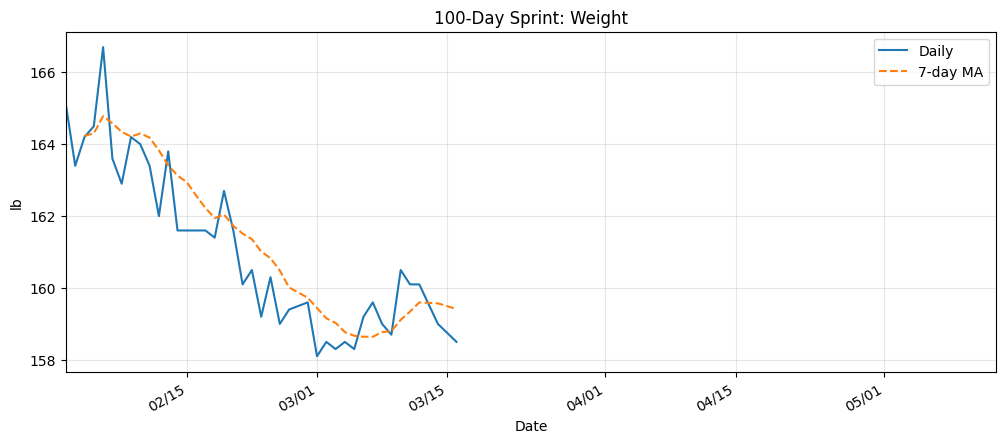

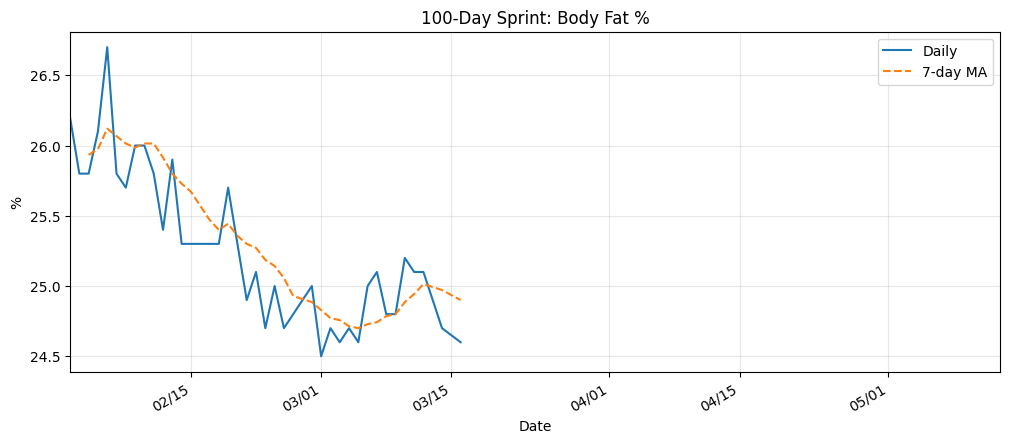

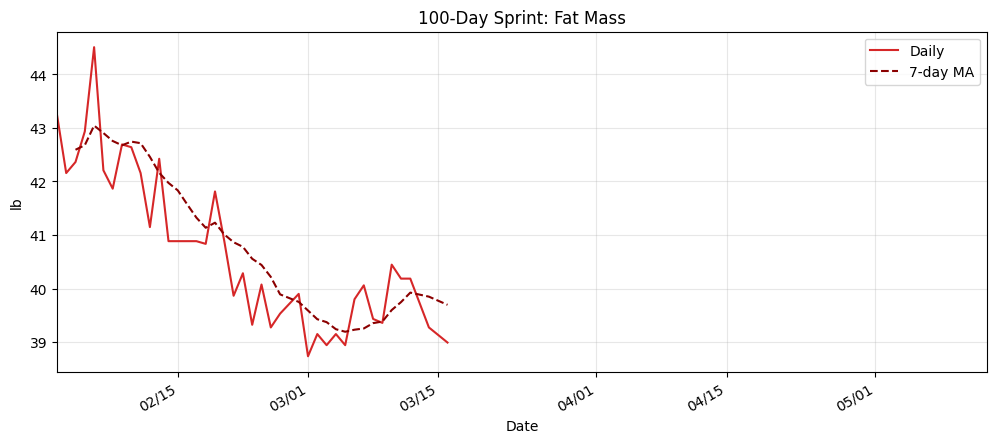

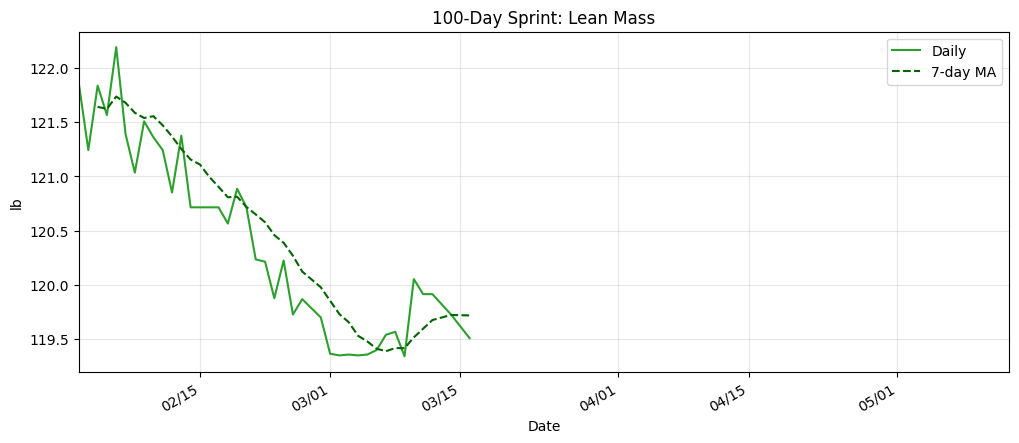

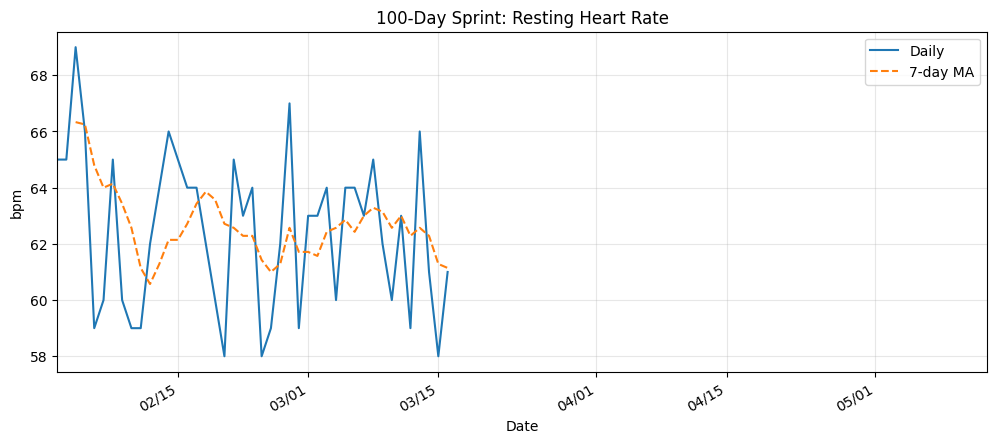

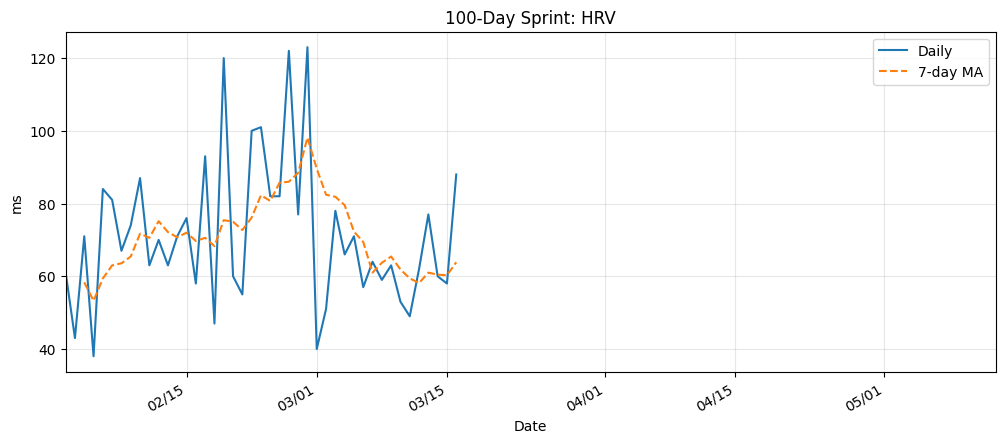

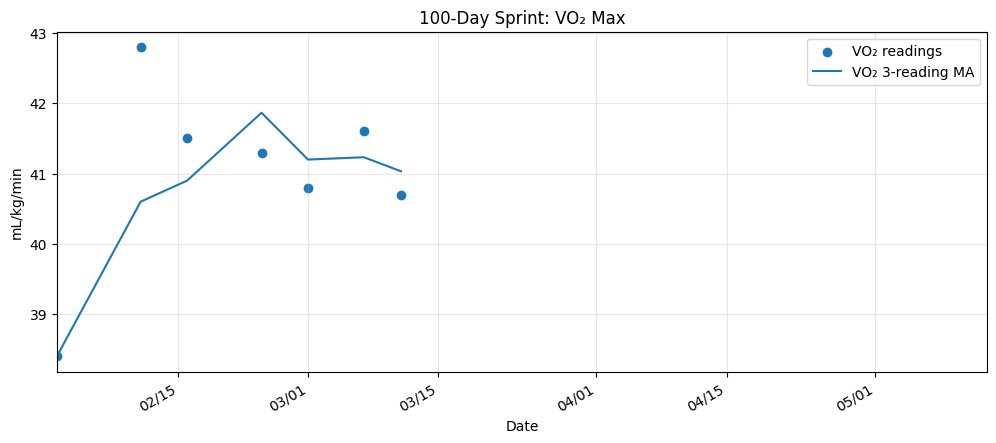

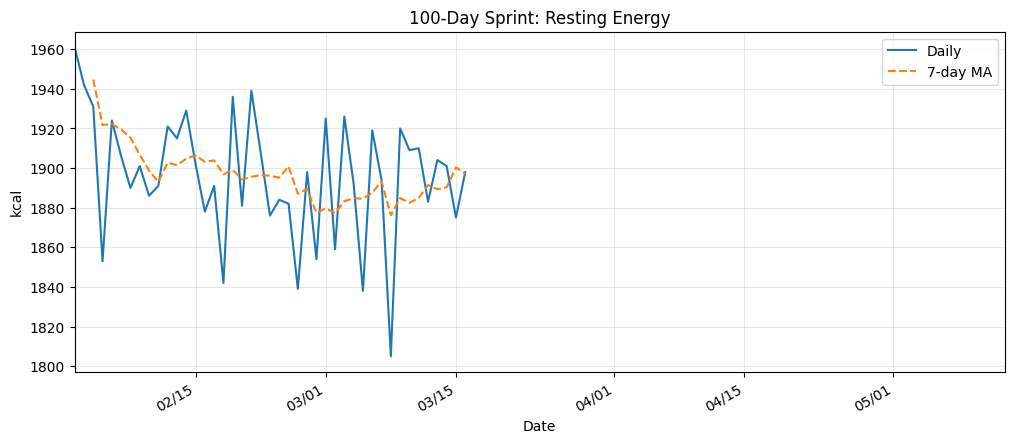

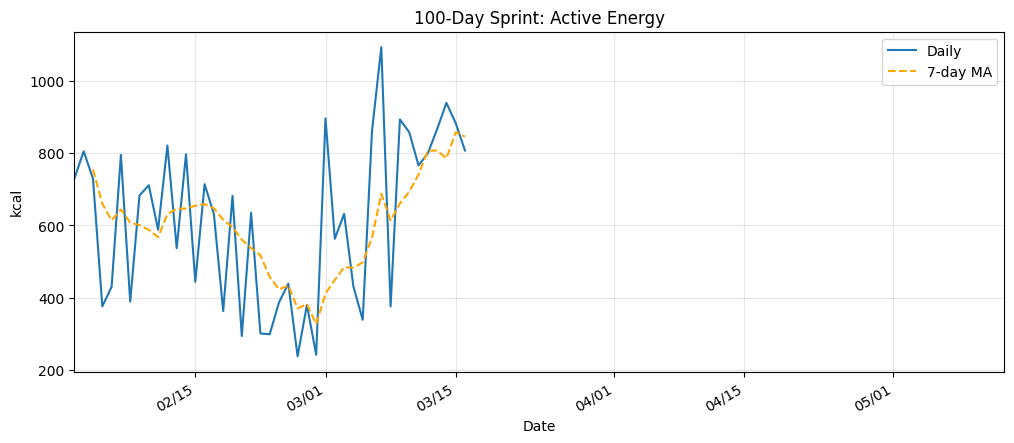

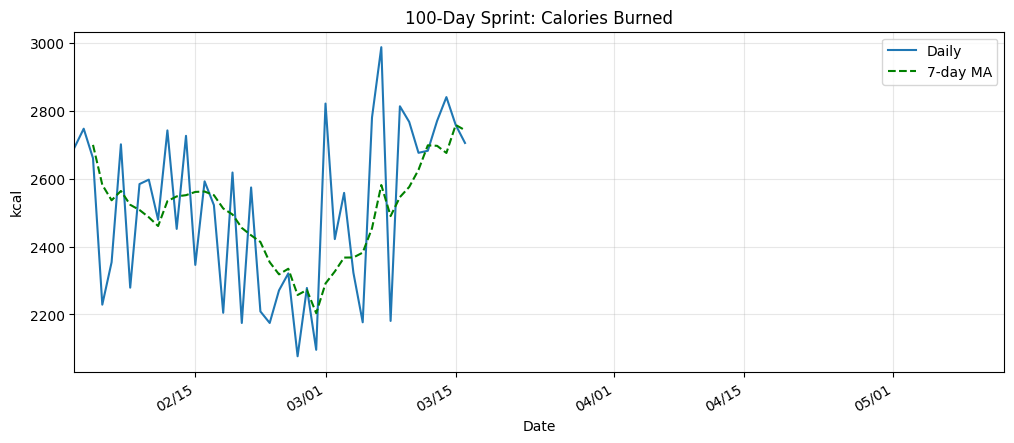

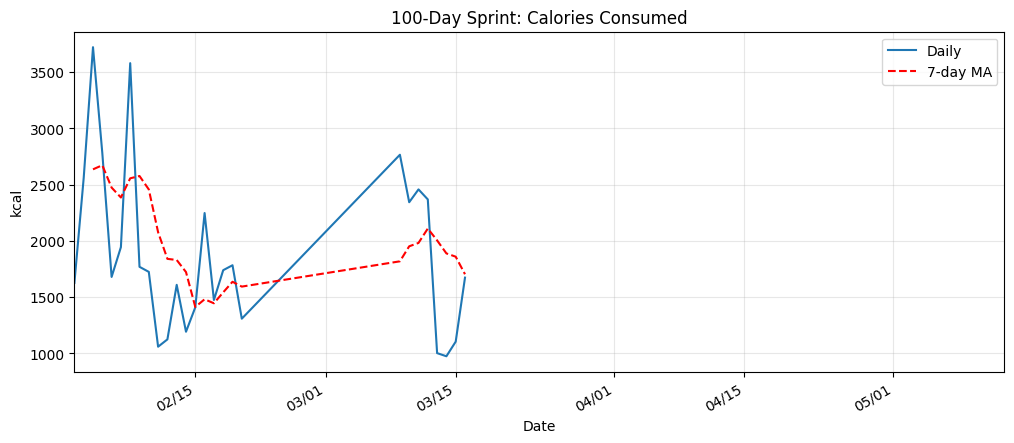

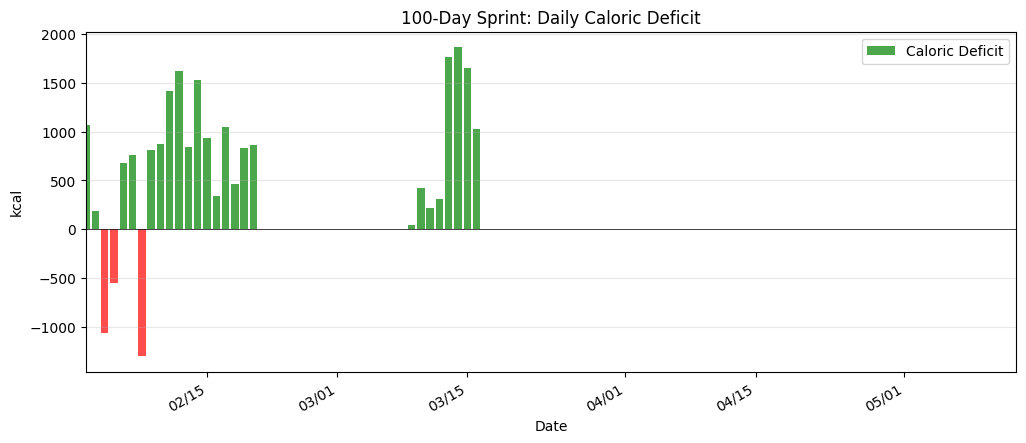

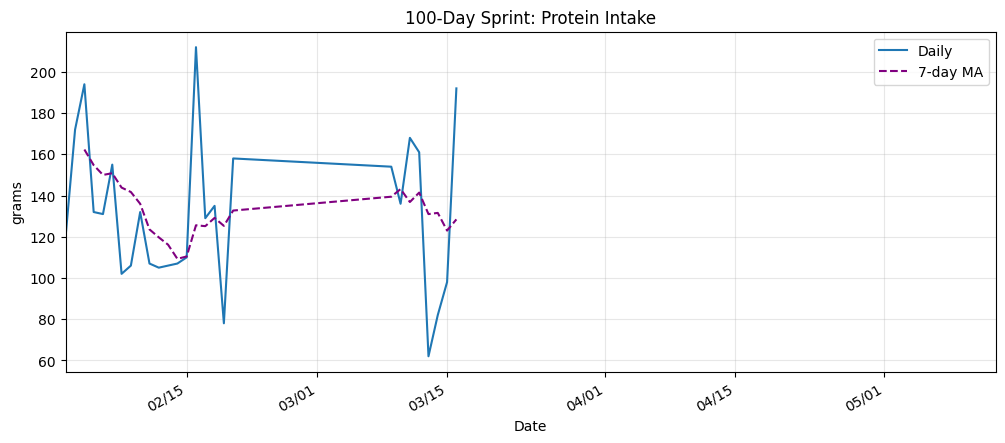

In [4]:
# 100-Day Sprint Dashboard (Feb 2 – May 13, 2026)
SPRINT_START = pd.Timestamp("2026-02-02")
SPRINT_END = pd.Timestamp("2026-05-13")
ds = df.loc[SPRINT_START:]

# Helper: filter valid values within sprint window
def sprint_valid(series):
    return series.loc[SPRINT_START:].dropna()

# Sprint moving averages
s_weight = sprint_valid(df["Weight"])
s_ma7_weight = s_weight.rolling(window=7, min_periods=3).mean()

s_bf = sprint_valid(df["BodyFatPct"])
s_ma7_bf = s_bf.rolling(window=7, min_periods=3).mean()

s_fat = sprint_valid(df["FatMass"])
s_ma7_fat = s_fat.rolling(window=7, min_periods=3).mean()

s_lean = sprint_valid(df["LeanMass"])
s_ma7_lean = s_lean.rolling(window=7, min_periods=3).mean()

s_rhr = sprint_valid(df["RHR"])
s_ma7_rhr = s_rhr.rolling(window=7, min_periods=3).mean()

s_hrv = sprint_valid(df["HRV"])
s_ma7_hrv = s_hrv.rolling(window=7, min_periods=3).mean()

s_vo2 = sprint_valid(df["VO2"])
s_vo2_ma3 = s_vo2.rolling(window=3, min_periods=1).mean() if len(s_vo2) > 0 else s_vo2

s_resting = sprint_valid(df["Resting Energy"])
s_ma7_resting = s_resting.rolling(window=7, min_periods=3).mean()

s_active = sprint_valid(df["Active Energy"])
s_ma7_active = s_active.rolling(window=7, min_periods=3).mean()

s_burned = sprint_valid(df["Calories Burned"])
s_ma7_burned = s_burned.rolling(window=7, min_periods=3).mean()

s_consumed = sprint_valid(df["Calories Consumed"])
s_ma7_consumed = s_consumed.rolling(window=7, min_periods=3).mean()

s_protein = sprint_valid(df["Protein"])
s_ma7_protein = s_protein.rolling(window=7, min_periods=3).mean()

s_deficit = sprint_valid(df["Deficit"])

date_fmt = DateFormatter("%m/%d")

# Sprint Weight
fig, ax = plt.subplots(figsize=(12, 5))
ax.plot(s_weight.index, s_weight, label="Daily")
ax.plot(s_ma7_weight.index, s_ma7_weight, linestyle="--", label="7-day MA")
ax.set_title("100-Day Sprint: Weight")
ax.set_xlabel("Date"); ax.set_ylabel("lb")
ax.set_xlim(SPRINT_START, SPRINT_END)
ax.xaxis.set_major_formatter(date_fmt); ax.legend(); ax.grid(True, alpha=0.3)
fig.autofmt_xdate()
fig.savefig("other/sprint_weight.png", bbox_inches="tight", dpi=160)

# Sprint Body Fat %
fig, ax = plt.subplots(figsize=(12, 5))
ax.plot(s_bf.index, s_bf, label="Daily")
ax.plot(s_ma7_bf.index, s_ma7_bf, linestyle="--", label="7-day MA")
ax.set_title("100-Day Sprint: Body Fat %")
ax.set_xlabel("Date"); ax.set_ylabel("%")
ax.set_xlim(SPRINT_START, SPRINT_END)
ax.xaxis.set_major_formatter(date_fmt); ax.legend(); ax.grid(True, alpha=0.3)
fig.autofmt_xdate()
fig.savefig("other/sprint_bodyfat.png", bbox_inches="tight", dpi=160)

# Sprint Fat Mass
fig, ax = plt.subplots(figsize=(12, 5))
ax.plot(s_fat.index, s_fat, label="Daily", color="tab:red")
ax.plot(s_ma7_fat.index, s_ma7_fat, linestyle="--", label="7-day MA", color="darkred")
ax.set_title("100-Day Sprint: Fat Mass")
ax.set_xlabel("Date"); ax.set_ylabel("lb")
ax.set_xlim(SPRINT_START, SPRINT_END)
ax.xaxis.set_major_formatter(date_fmt); ax.legend(); ax.grid(True, alpha=0.3)
fig.autofmt_xdate()
fig.savefig("other/sprint_fat_mass.png", bbox_inches="tight", dpi=160)

# Sprint Lean Mass
fig, ax = plt.subplots(figsize=(12, 5))
ax.plot(s_lean.index, s_lean, label="Daily", color="tab:green")
ax.plot(s_ma7_lean.index, s_ma7_lean, linestyle="--", label="7-day MA", color="darkgreen")
ax.set_title("100-Day Sprint: Lean Mass")
ax.set_xlabel("Date"); ax.set_ylabel("lb")
ax.set_xlim(SPRINT_START, SPRINT_END)
ax.xaxis.set_major_formatter(date_fmt); ax.legend(); ax.grid(True, alpha=0.3)
fig.autofmt_xdate()
fig.savefig("other/sprint_lean_mass.png", bbox_inches="tight", dpi=160)

# Sprint RHR
fig, ax = plt.subplots(figsize=(12, 5))
ax.plot(s_rhr.index, s_rhr, label="Daily")
ax.plot(s_ma7_rhr.index, s_ma7_rhr, linestyle="--", label="7-day MA")
ax.set_title("100-Day Sprint: Resting Heart Rate")
ax.set_xlabel("Date"); ax.set_ylabel("bpm")
ax.set_xlim(SPRINT_START, SPRINT_END)
ax.xaxis.set_major_formatter(date_fmt); ax.legend(); ax.grid(True, alpha=0.3)
fig.autofmt_xdate()
fig.savefig("other/sprint_rhr.png", bbox_inches="tight", dpi=160)

# Sprint HRV
fig, ax = plt.subplots(figsize=(12, 5))
ax.plot(s_hrv.index, s_hrv, label="Daily")
ax.plot(s_ma7_hrv.index, s_ma7_hrv, linestyle="--", label="7-day MA")
ax.set_title("100-Day Sprint: HRV")
ax.set_xlabel("Date"); ax.set_ylabel("ms")
ax.set_xlim(SPRINT_START, SPRINT_END)
ax.xaxis.set_major_formatter(date_fmt); ax.legend(); ax.grid(True, alpha=0.3)
fig.autofmt_xdate()
fig.savefig("other/sprint_hrv.png", bbox_inches="tight", dpi=160)

# Sprint VO2
if len(s_vo2) > 0:
    fig, ax = plt.subplots(figsize=(12, 5))
    ax.scatter(s_vo2.index, s_vo2, label="VO₂ readings")
    ax.plot(s_vo2_ma3.index, s_vo2_ma3, label="VO₂ 3-reading MA")
    ax.set_title("100-Day Sprint: VO₂ Max")
    ax.set_xlabel("Date"); ax.set_ylabel("mL/kg/min")
    ax.set_xlim(SPRINT_START, SPRINT_END)
    ax.xaxis.set_major_formatter(date_fmt); ax.legend(); ax.grid(True, alpha=0.3)
    fig.autofmt_xdate()
    fig.savefig("other/sprint_vo2.png", bbox_inches="tight", dpi=160)

# Sprint Resting Energy
if len(s_resting) > 0:
    fig, ax = plt.subplots(figsize=(12, 5))
    ax.plot(s_resting.index, s_resting, label="Daily")
    ax.plot(s_ma7_resting.index, s_ma7_resting, linestyle="--", label="7-day MA")
    ax.set_title("100-Day Sprint: Resting Energy")
    ax.set_xlabel("Date"); ax.set_ylabel("kcal")
    ax.set_xlim(SPRINT_START, SPRINT_END)
    ax.xaxis.set_major_formatter(date_fmt); ax.legend(); ax.grid(True, alpha=0.3)
    fig.autofmt_xdate()
    fig.savefig("other/sprint_resting_energy.png", bbox_inches="tight", dpi=160)

# Sprint Active Energy
if len(s_active) > 0:
    fig, ax = plt.subplots(figsize=(12, 5))
    ax.plot(s_active.index, s_active, label="Daily")
    ax.plot(s_ma7_active.index, s_ma7_active, linestyle="--", label="7-day MA", color="orange")
    ax.set_title("100-Day Sprint: Active Energy")
    ax.set_xlabel("Date"); ax.set_ylabel("kcal")
    ax.set_xlim(SPRINT_START, SPRINT_END)
    ax.xaxis.set_major_formatter(date_fmt); ax.legend(); ax.grid(True, alpha=0.3)
    fig.autofmt_xdate()
    fig.savefig("other/sprint_active_energy.png", bbox_inches="tight", dpi=160)

# Sprint Calories Burned
if len(s_burned) > 0:
    fig, ax = plt.subplots(figsize=(12, 5))
    ax.plot(s_burned.index, s_burned, label="Daily")
    ax.plot(s_ma7_burned.index, s_ma7_burned, linestyle="--", label="7-day MA", color="green")
    ax.set_title("100-Day Sprint: Calories Burned")
    ax.set_xlabel("Date"); ax.set_ylabel("kcal")
    ax.set_xlim(SPRINT_START, SPRINT_END)
    ax.xaxis.set_major_formatter(date_fmt); ax.legend(); ax.grid(True, alpha=0.3)
    fig.autofmt_xdate()
    fig.savefig("other/sprint_calories_burned.png", bbox_inches="tight", dpi=160)

# Sprint Calories Consumed
if len(s_consumed) > 0:
    fig, ax = plt.subplots(figsize=(12, 5))
    ax.plot(s_consumed.index, s_consumed, label="Daily")
    ax.plot(s_ma7_consumed.index, s_ma7_consumed, linestyle="--", label="7-day MA", color="red")
    ax.set_title("100-Day Sprint: Calories Consumed")
    ax.set_xlabel("Date"); ax.set_ylabel("kcal")
    ax.set_xlim(SPRINT_START, SPRINT_END)
    ax.xaxis.set_major_formatter(date_fmt); ax.legend(); ax.grid(True, alpha=0.3)
    fig.autofmt_xdate()
    fig.savefig("other/sprint_calories_consumed.png", bbox_inches="tight", dpi=160)

# Sprint Caloric Deficit
if len(s_deficit) > 0:
    fig, ax = plt.subplots(figsize=(12, 5))
    colors = ["green" if x > 0 else "red" for x in s_deficit]
    ax.bar(s_deficit.index, s_deficit, label="Caloric Deficit", alpha=0.7, color=colors)
    ax.axhline(y=0, color="black", linestyle="-", linewidth=0.5)
    ax.set_title("100-Day Sprint: Daily Caloric Deficit")
    ax.set_xlabel("Date"); ax.set_ylabel("kcal")
    ax.set_xlim(SPRINT_START, SPRINT_END)
    ax.xaxis.set_major_formatter(date_fmt); ax.legend(); ax.grid(True, alpha=0.3, axis="y")
    fig.autofmt_xdate()
    fig.savefig("other/sprint_deficit.png", bbox_inches="tight", dpi=160)

# Sprint Protein
if len(s_protein) > 0:
    fig, ax = plt.subplots(figsize=(12, 5))
    ax.plot(s_protein.index, s_protein, label="Daily")
    ax.plot(s_ma7_protein.index, s_ma7_protein, linestyle="--", label="7-day MA", color="purple")
    ax.set_title("100-Day Sprint: Protein Intake")
    ax.set_xlabel("Date"); ax.set_ylabel("grams")
    ax.set_xlim(SPRINT_START, SPRINT_END)
    ax.xaxis.set_major_formatter(date_fmt); ax.legend(); ax.grid(True, alpha=0.3)
    fig.autofmt_xdate()
    fig.savefig("other/sprint_protein.png", bbox_inches="tight", dpi=160)

print("✓ 100-Day Sprint dashboard generated (Feb 2 – May 13, 2026)")

✓ Health Score plots generated
  Latest score: 82.4th percentile
  Components: Fat Mass=90, RHR=99, HRV=76, VO2=65


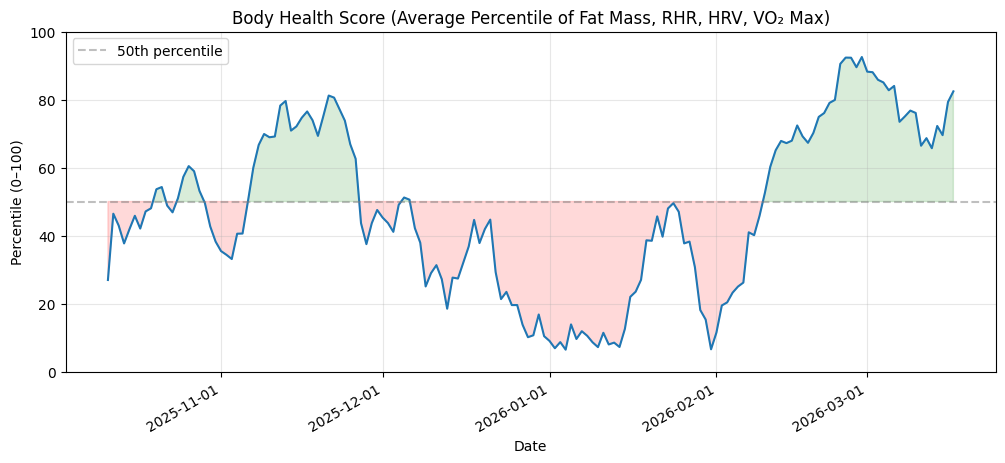

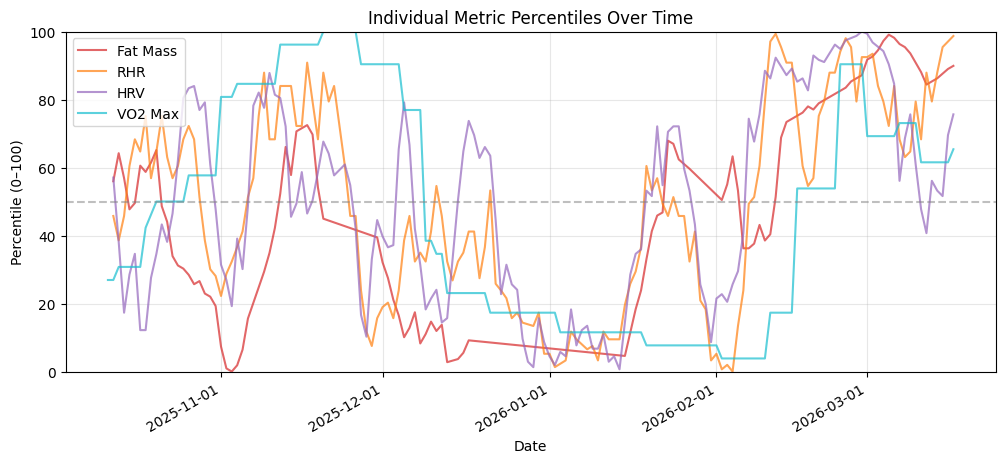

In [6]:
# Body Health Percentile Score
# Uses 7-day MA of: Fat Mass (lbs), RHR, HRV, VO2 Max
# Each value is ranked as a percentile within its own full history
# Fat Mass & RHR: lower is better (inverted percentile)
# HRV & VO2: higher is better
import numpy as np

def to_percentile(series, invert=False):
    """Convert each value to its percentile rank within the full sample."""
    valid = series.dropna()
    if len(valid) == 0:
        return series
    ranks = valid.rank(pct=True) * 100
    if invert:
        ranks = 100 - ranks
    return ranks

# Use the 7-day MAs computed in cell 1
fat_pct = to_percentile(ma7_fat, invert=True)      # lower fat = better
rhr_pct = to_percentile(ma7_rhr, invert=True)      # lower RHR = better
hrv_pct = to_percentile(ma7_hrv, invert=False)     # higher HRV = better
vo2_pct = to_percentile(vo2_ma3, invert=False)     # higher VO2 = better

# Combine into a single DataFrame, forward-fill VO2 (sparse readings)
pct_df = pd.DataFrame({
    "Fat Mass": fat_pct,
    "RHR": rhr_pct,
    "HRV": hrv_pct,
    "VO2 Max": vo2_pct,
})
pct_df = pct_df.sort_index()
pct_df["VO2 Max"] = pct_df["VO2 Max"].ffill()

# Average percentile (require at least 3 of 4 metrics)
pct_df["HealthScore"] = pct_df[["Fat Mass", "RHR", "HRV", "VO2 Max"]].mean(axis=1)
pct_valid = pct_df["HealthScore"].dropna()

# --- Plot 1: Composite Health Score ---
fig, ax = plt.subplots(figsize=(12, 5))
ax.plot(pct_valid.index, pct_valid, color="tab:blue", linewidth=1.5)
ax.axhline(y=50, color="gray", linestyle="--", alpha=0.5, label="50th percentile")
ax.fill_between(pct_valid.index, pct_valid, 50, where=pct_valid >= 50,
                alpha=0.15, color="green", interpolate=True)
ax.fill_between(pct_valid.index, pct_valid, 50, where=pct_valid < 50,
                alpha=0.15, color="red", interpolate=True)
ax.set_title("Body Health Score (Average Percentile of Fat Mass, RHR, HRV, VO₂ Max)")
ax.set_xlabel("Date")
ax.set_ylabel("Percentile (0–100)")
ax.set_ylim(0, 100)
ax.xaxis.set_major_formatter(DateFormatter("%Y-%m-%d"))
ax.legend()
ax.grid(True, alpha=0.3)
fig.autofmt_xdate()
fig.savefig("other/health_score.png", bbox_inches="tight", dpi=160)

# --- Plot 2: Individual metric percentiles ---
fig, ax = plt.subplots(figsize=(12, 5))
for col, color in [("Fat Mass", "tab:red"), ("RHR", "tab:orange"),
                    ("HRV", "tab:purple"), ("VO2 Max", "tab:cyan")]:
    valid = pct_df[col].dropna()
    if len(valid) > 0:
        ax.plot(valid.index, valid, label=col, color=color, alpha=0.7)
ax.axhline(y=50, color="gray", linestyle="--", alpha=0.5)
ax.set_title("Individual Metric Percentiles Over Time")
ax.set_xlabel("Date")
ax.set_ylabel("Percentile (0–100)")
ax.set_ylim(0, 100)
ax.xaxis.set_major_formatter(DateFormatter("%Y-%m-%d"))
ax.legend(loc="upper left")
ax.grid(True, alpha=0.3)
fig.autofmt_xdate()
fig.savefig("other/health_score_individual.png", bbox_inches="tight", dpi=160)

print(f"✓ Health Score plots generated")
print(f"  Latest score: {pct_valid.iloc[-1]:.1f}th percentile")
print(f"  Components: Fat Mass={fat_pct.iloc[-1]:.0f}, RHR={rhr_pct.iloc[-1]:.0f}, HRV={hrv_pct.iloc[-1]:.0f}, VO2={vo2_pct.iloc[-1]:.0f}")